# Sales Leads & Loan Data Analysis

Analysis of:
- Sales Leads ABC from Quizzes.xlsx
- loan-data.xlsx

**Created:** January 27, 2026

In [98]:
# Install required packages
# Uncomment the line below if you need to install packages:
# !pip install --user pandas numpy matplotlib seaborn openpyxl

print("Packages should be installed. Re-run this notebook from the top.")

Packages should be installed. Re-run this notebook from the top.


## Install Required Packages (Run Once)

If you get import errors, run this cell first:

In [99]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Try to import seaborn, but it's optional
try:
    import seaborn as sns
    sns.set_palette('husl')
    print('✓ Seaborn loaded')
except ImportError:
    print('ℹ Seaborn not available (optional - charts will still work)')
    sns = None

from datetime import datetime

# Configure display
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.style.use('seaborn-v0_8-whitegrid') if sns else plt.style.use('default')
%matplotlib inline

print('✓ Libraries loaded!')

ℹ Seaborn not available (optional - charts will still work)
✓ Libraries loaded!


## 1. Load Sales Leads Data

In [100]:
# Load sales leads data
# The Excel file has actual data starting from row 2 (index 1)
sales_df = pd.read_excel('Sales Leads ABC from Quizzes.xlsx')

# The first row contains the actual column names
# Set the first row as column names
sales_df.columns = sales_df.iloc[0]
sales_df = sales_df.drop(0).reset_index(drop=True)

# Clean up the dataframe - remove completely empty rows/columns
sales_df = sales_df.dropna(how='all', axis=0)
sales_df = sales_df.dropna(how='all', axis=1)

# Remove the None column name if it exists
sales_df = sales_df.loc[:, sales_df.columns.notna()]

print(f'Sales Leads Dataset: {sales_df.shape[0]} rows, {sales_df.shape[1]} columns')
print('\nColumns:', list(sales_df.columns))
print('\nFirst few rows:')
sales_df.head()

Sales Leads Dataset: 1500 rows, 6 columns

Columns: ['id', 'Source', 'Purchase', 'Profit', 'Summary 1', 'Summary 1 (transposed)']

First few rows:


,id,Source,Purchase,Profit,Summary 1,Summary 1 (transposed)
0,1,List A,Buy,441,NaN,NaN
1,2,List A,No Buy,-82,List A,Buy
2,3,List A,No Buy,-33,List B,No Buy
3,4,List A,Buy,416,List C,NaN
4,5,List A,Buy,314,NaN,NaN


In [101]:
# Explore sales data structure
print('=== Sales Leads Info ===')
print('\nColumn names:')
print(sales_df.columns.tolist())
print('\nData types:')
print(sales_df.dtypes)
print('\nMissing values:')
print(sales_df.isnull().sum())
print('\nBasic statistics:')
sales_df.describe()

=== Sales Leads Info ===

Column names:
['id', 'Source', 'Purchase', 'Profit', 'Summary 1', 'Summary 1 (transposed)']

Data types:
0
id                        object
Source                       str
Purchase                     str
Profit                    object
Summary 1                    str
Summary 1 (transposed)       str
dtype: object

Missing values:
0
id                           0
Source                       0
Purchase                     0
Profit                       0
Summary 1                 1490
Summary 1 (transposed)    1498
dtype: int64

Basic statistics:


,id,Source,Purchase,Profit,Summary 1,Summary 1 (transposed)
count,1500,1500,1500,1500,10,2
unique,1500,3,2,334,4,2
top,1,List A,No Buy,-68,List A,Buy
freq,1,500,1205,23,3,1


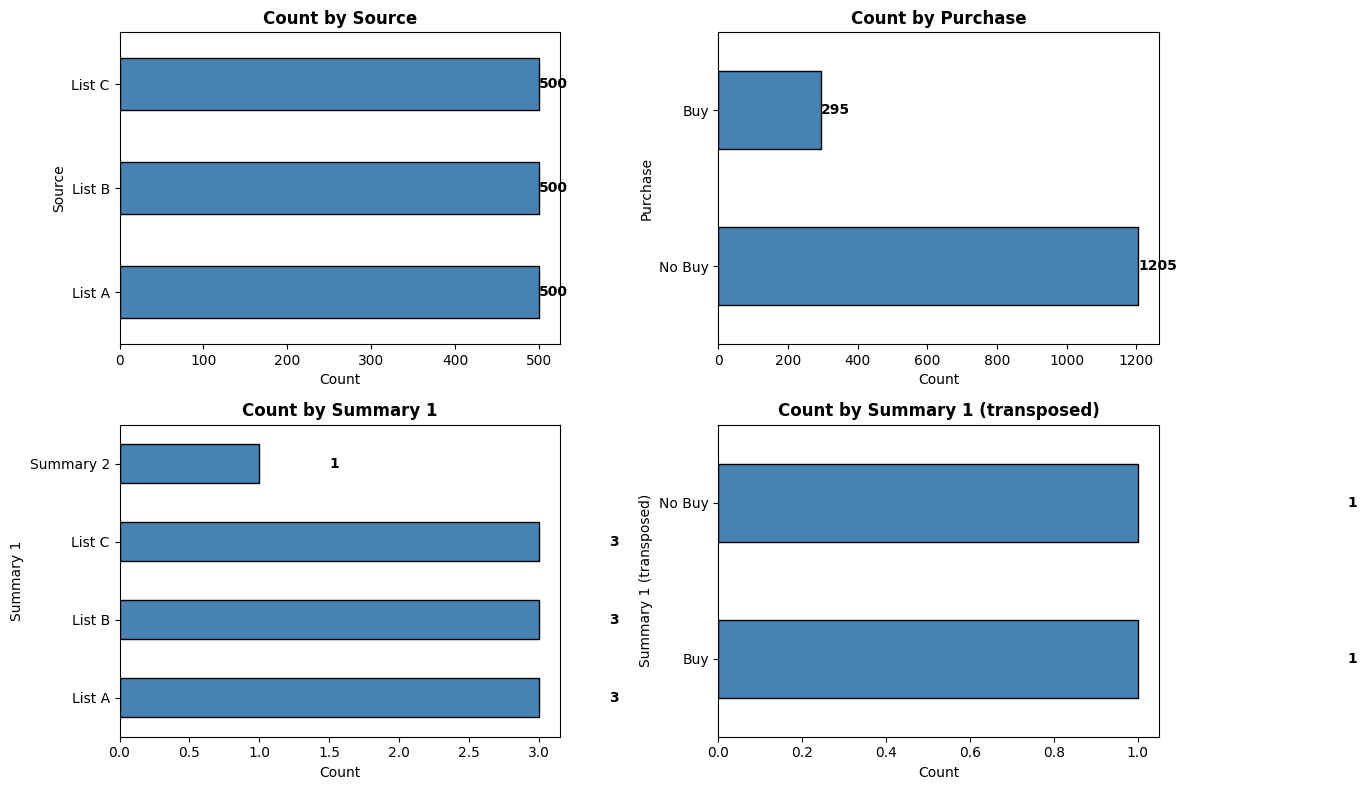

In [102]:
# VISUALIZE TOP CATEGORICAL VARIABLES
categorical_cols = sales_df.select_dtypes(include=['object', 'category', 'string']).columns

# Only show categorical columns with 2-15 unique values (good for bar charts)
plottable_cats = [col for col in categorical_cols if 2 <= sales_df[col].nunique() <= 15]

if len(plottable_cats) > 0:
    n_cols = min(len(plottable_cats), 6)  # Max 6 charts
    n_rows = (n_cols + 1) // 2
    
    fig, axes = plt.subplots(n_rows, 2, figsize=(14, n_rows * 4))
    axes = axes.flatten() if n_cols > 1 else [axes]
    
    for idx, col in enumerate(plottable_cats[:6]):
        ax = axes[idx]
        
        value_counts = sales_df[col].value_counts().head(10)
        value_counts.plot(kind='barh', ax=ax, color='steelblue', edgecolor='black')
        
        ax.set_title(f'Count by {col}', fontweight='bold', fontsize=12)
        ax.set_xlabel('Count')
        ax.set_ylabel(col)
        
        # Add count labels
        for i, v in enumerate(value_counts.values):
            ax.text(v + 0.5, i, str(v), va='center', fontweight='bold')
    
    # Hide empty subplots
    for idx in range(len(plottable_cats[:6]), len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    plt.show()
else:
    print("No suitable categorical columns for visualization.")

In [103]:
# VISUALIZE NUMERIC DISTRIBUTIONS
numeric_cols = sales_df.select_dtypes(include=[np.number]).columns

if len(numeric_cols) > 0:
    n_cols = len(numeric_cols)
    n_rows = (n_cols + 2) // 3  # 3 columns per row
    
    fig, axes = plt.subplots(n_rows, 3, figsize=(15, n_rows * 4))
    axes = axes.flatten() if n_cols > 1 else [axes]
    
    for idx, col in enumerate(numeric_cols):
        ax = axes[idx]
        
        # Histogram with mean and median lines
        sales_df[col].hist(bins=30, ax=ax, edgecolor='black', alpha=0.7, color='steelblue')
        
        mean_val = sales_df[col].mean()
        median_val = sales_df[col].median()
        
        ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
        ax.axvline(median_val, color='green', linestyle='--', linewidth=2, label=f'Median: {median_val:.2f}')
        
        ax.set_title(f'Distribution of {col}', fontweight='bold')
        ax.set_xlabel(col)
        ax.set_ylabel('Frequency')
        ax.legend()
        ax.grid(alpha=0.3)
    
    # Hide empty subplots
    for idx in range(len(numeric_cols), len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    plt.show()
else:
    print("No numeric columns to visualize.")

No numeric columns to visualize.


In [104]:
# KEY INSIGHTS & SUMMARY
print("="*70)
print("KEY INSIGHTS")
print("="*70)

# Try to find important columns and provide insights
print("\n💡 Quick Summary:")

# Total records
print(f"   • Total sales leads: {len(sales_df):,}")

# Look for buy/decision column
buy_cols = [col for col in sales_df.columns if 'buy' in col.lower() or 'decision' in col.lower() or 'purchase' in col.lower()]
if buy_cols:
    for col in buy_cols:
        print(f"\n   📊 {col} breakdown:")
        for val, count in sales_df[col].value_counts().items():
            pct = count / len(sales_df) * 100
            print(f"      • {val}: {count} ({pct:.1f}%)")

# Look for score/rating columns
score_cols = [col for col in sales_df.columns if 'score' in col.lower() or 'rating' in col.lower()]
if score_cols:
    for col in score_cols:
        if sales_df[col].dtype in ['int64', 'float64']:
            avg_score = sales_df[col].mean()
            min_score = sales_df[col].min()
            max_score = sales_df[col].max()
            print(f"\n   📈 {col}:")
            print(f"      • Average: {avg_score:.2f}")
            print(f"      • Range: {min_score} to {max_score}")

# Look for date columns
date_cols = [col for col in sales_df.columns if 'date' in col.lower() or 'time' in col.lower()]
if date_cols:
    print(f"\n   📅 Date columns found: {', '.join(date_cols)}")

print("\n" + "="*70)

KEY INSIGHTS

💡 Quick Summary:
   • Total sales leads: 1,500

   📊 Purchase breakdown:
      • No Buy: 1205 (80.3%)
      • Buy: 295 (19.7%)



In [105]:
# DATA QUALITY REPORT
print("="*70)
print("DATA QUALITY REPORT")
print("="*70)

print("\n🔍 Missing Values:")
missing = sales_df.isnull().sum()
if missing.sum() == 0:
    print("   ✅ No missing values found!")
else:
    missing_df = pd.DataFrame({
        'Column': missing[missing > 0].index,
        'Missing Count': missing[missing > 0].values,
        'Percentage': (missing[missing > 0] / len(sales_df) * 100).round(2)
    })
    display(missing_df)

print("\n🔍 Duplicate Rows:")
duplicates = sales_df.duplicated().sum()
if duplicates == 0:
    print("   ✅ No duplicate rows found!")
else:
    print(f"   ⚠️  Found {duplicates} duplicate rows ({duplicates/len(sales_df)*100:.2f}%)")

print("\n🔍 Data Types:")
dtype_summary = sales_df.dtypes.value_counts()
for dtype, count in dtype_summary.items():
    print(f"   • {dtype}: {count} columns")

print("\n" + "="*70)

DATA QUALITY REPORT

🔍 Missing Values:


,Column,Missing Count,Percentage
0,,,
Summary 1,Summary 1,1490,99.33
Summary 1 (transposed),Summary 1 (transposed),1498,99.87



🔍 Duplicate Rows:
   ✅ No duplicate rows found!

🔍 Data Types:
   • str: 4 columns
   • object: 2 columns



In [106]:
# CATEGORICAL COLUMNS SUMMARY
print("="*70)
print("CATEGORICAL COLUMNS - VALUE COUNTS")
print("="*70)

categorical_cols = sales_df.select_dtypes(include=['object', 'category', 'string']).columns

for col in categorical_cols:
    unique_count = sales_df[col].nunique()
    print(f"\n📌 {col}")
    print(f"   Unique values: {unique_count}")
    
    # Show top 10 values
    value_counts = sales_df[col].value_counts()
    if len(value_counts) <= 10:
        print(f"\n   All values:")
        for val, count in value_counts.items():
            pct = (count / len(sales_df) * 100)
            print(f"      • {val:30s}: {count:5d} ({pct:5.1f}%)")
    else:
        print(f"\n   Top 10 values:")
        for val, count in value_counts.head(10).items():
            pct = (count / len(sales_df) * 100)
            print(f"      • {val:30s}: {count:5d} ({pct:5.1f}%)")
        remaining = len(value_counts) - 10
        print(f"      ... and {remaining} more values")

print("\n" + "="*70)

CATEGORICAL COLUMNS - VALUE COUNTS

📌 id
   Unique values: 1500

   Top 10 values:


ValueError: Unknown format code 's' for object of type 'int'

In [107]:
# STATISTICAL SUMMARY FOR NUMERIC COLUMNS
print("="*70)
print("NUMERIC COLUMNS - STATISTICAL SUMMARY")
print("="*70)

numeric_cols = sales_df.select_dtypes(include=[np.number]).columns
if len(numeric_cols) > 0:
    display(sales_df[numeric_cols].describe().round(2))
else:
    print("No numeric columns found in the dataset.")

print("\n" + "="*70)

NUMERIC COLUMNS - STATISTICAL SUMMARY
No numeric columns found in the dataset.



In [108]:
# FIRST & LAST ROWS
print("="*70)
print("SAMPLE DATA - FIRST 10 ROWS")
print("="*70)
display(sales_df.head(10))

print("\n" + "="*70)
print("SAMPLE DATA - LAST 5 ROWS")
print("="*70)
display(sales_df.tail(5))

SAMPLE DATA - FIRST 10 ROWS


,id,Source,Purchase,Profit,Summary 1,Summary 1 (transposed)
0,1,List A,Buy,441,NaN,NaN
1,2,List A,No Buy,-82,List A,Buy
2,3,List A,No Buy,-33,List B,No Buy
3,4,List A,Buy,416,List C,NaN
4,5,List A,Buy,314,NaN,NaN
5,6,List A,No Buy,-164,NaN,NaN
6,7,List A,Buy,300,NaN,NaN
7,8,List A,Buy,340,NaN,NaN
8,9,List A,No Buy,-118,NaN,NaN
9,10,List A,No Buy,-70,NaN,NaN



SAMPLE DATA - LAST 5 ROWS


,id,Source,Purchase,Profit,Summary 1,Summary 1 (transposed)
1495,1496,List C,No Buy,-47,NaN,NaN
1496,1497,List C,No Buy,-47,NaN,NaN
1497,1498,List C,No Buy,-57,NaN,NaN
1498,1499,List C,Buy,525,NaN,NaN
1499,1500,List C,Buy,415,NaN,NaN


In [109]:
# DATASET OVERVIEW
print("="*70)
print("SALES LEADS DATASET OVERVIEW")
print("="*70)

print(f"\n📊 Dataset Size:")
print(f"   • Total Rows: {sales_df.shape[0]:,}")
print(f"   • Total Columns: {sales_df.shape[1]}")

print(f"\n📋 Column Names:")
for i, col in enumerate(sales_df.columns, 1):
    dtype = str(sales_df[col].dtype)
    null_count = sales_df[col].isnull().sum()
    null_pct = (null_count / len(sales_df) * 100)
    print(f"   {i:2d}. {col:30s} [{dtype:10s}] - {null_count:3d} missing ({null_pct:.1f}%)")

print(f"\n💾 Memory Usage:")
print(f"   • Total: {sales_df.memory_usage(deep=True).sum() / 1024:.2f} KB")

print("\n" + "="*70)

SALES LEADS DATASET OVERVIEW

📊 Dataset Size:
   • Total Rows: 1,500
   • Total Columns: 6

📋 Column Names:
    1. id                             [object    ] -   0 missing (0.0%)
    2. Source                         [str       ] -   0 missing (0.0%)
    3. Purchase                       [str       ] -   0 missing (0.0%)
    4. Profit                         [object    ] -   0 missing (0.0%)
    5. Summary 1                      [str       ] - 1490 missing (99.3%)
    6. Summary 1 (transposed)         [str       ] - 1498 missing (99.9%)

💾 Memory Usage:
   • Total: 359.89 KB



## Data Description & Summary

## 2. Load Loan Data

In [110]:
# Load loan data
# This file has proper headers already
loan_df = pd.read_excel('loan-data.xlsx')

print(f'Loan Dataset: {loan_df.shape[0]} rows, {loan_df.shape[1]} columns')
print('\nColumns:', list(loan_df.columns))
print('\nFirst few rows:')
loan_df.head()

Loan Dataset: 2500 rows, 10 columns

Columns: ['ID', 'Loan Type', 'Debt to Income Ratio', 'Fraudlent Loan', 'Age', 'Co-Signer', 'Gender', 'Postal Worker', 'Loan Outcome', 'Loan Value at Origination']

First few rows:


,ID,Loan Type,Debt to Income Ratio,Fraudlent Loan,Age,Co-Signer,Gender,Postal Worker,Loan Outcome,Loan Value at Origination
0,10001,New Car,0.18,Good Loan,49,Co-Signer,Male,Non-Postal,Paid Off,15074.633944
1,10002,New Car,0.62,Bad Loan,70,No Co-Signer,Female,Non-Postal,Default,23080.336275
2,10003,Used Car,0.80,Good Loan,36,No Co-Signer,Female,Non-Postal,Paid Off,26584.064304
3,10004,New Car,0.75,Good Loan,28,No Co-Signer,Male,Non-Postal,Paid Off,26807.877824
4,10005,New Car,0.36,Good Loan,28,No Co-Signer,Female,Non-Postal,Paid Off,26392.601195


In [111]:
# LOAN DATA - COMPREHENSIVE OVERVIEW
print('='*70)
print('LOAN DATA OVERVIEW')
print('='*70)

print(f"\n📊 Dataset Size:")
print(f"   • Total Loans: {loan_df.shape[0]:,}")
print(f"   • Total Columns: {loan_df.shape[1]}")

print(f"\n📋 Columns:")
for i, col in enumerate(loan_df.columns, 1):
    dtype = str(loan_df[col].dtype)
    null_count = loan_df[col].isnull().sum()
    unique = loan_df[col].nunique()
    print(f"   {i:2d}. {col:30s} [{dtype:10s}] - {unique:5d} unique values")

print(f"\n💾 Memory Usage: {loan_df.memory_usage(deep=True).sum() / 1024:.2f} KB")
print('='*70)

LOAN DATA OVERVIEW

📊 Dataset Size:
   • Total Loans: 2,500
   • Total Columns: 10

📋 Columns:
    1. ID                             [int64     ] -  2500 unique values
    2. Loan Type                      [str       ] -     2 unique values
    3. Debt to Income Ratio           [float64   ] -    76 unique values
    4. Fraudlent Loan                 [str       ] -     2 unique values
    5. Age                            [int64     ] -    63 unique values
    6. Co-Signer                      [str       ] -     2 unique values
    7. Gender                         [str       ] -     2 unique values
    8. Postal Worker                  [str       ] -     2 unique values
    9. Loan Outcome                   [str       ] -     2 unique values
   10. Loan Value at Origination      [float64   ] -  2500 unique values

💾 Memory Usage: 922.62 KB


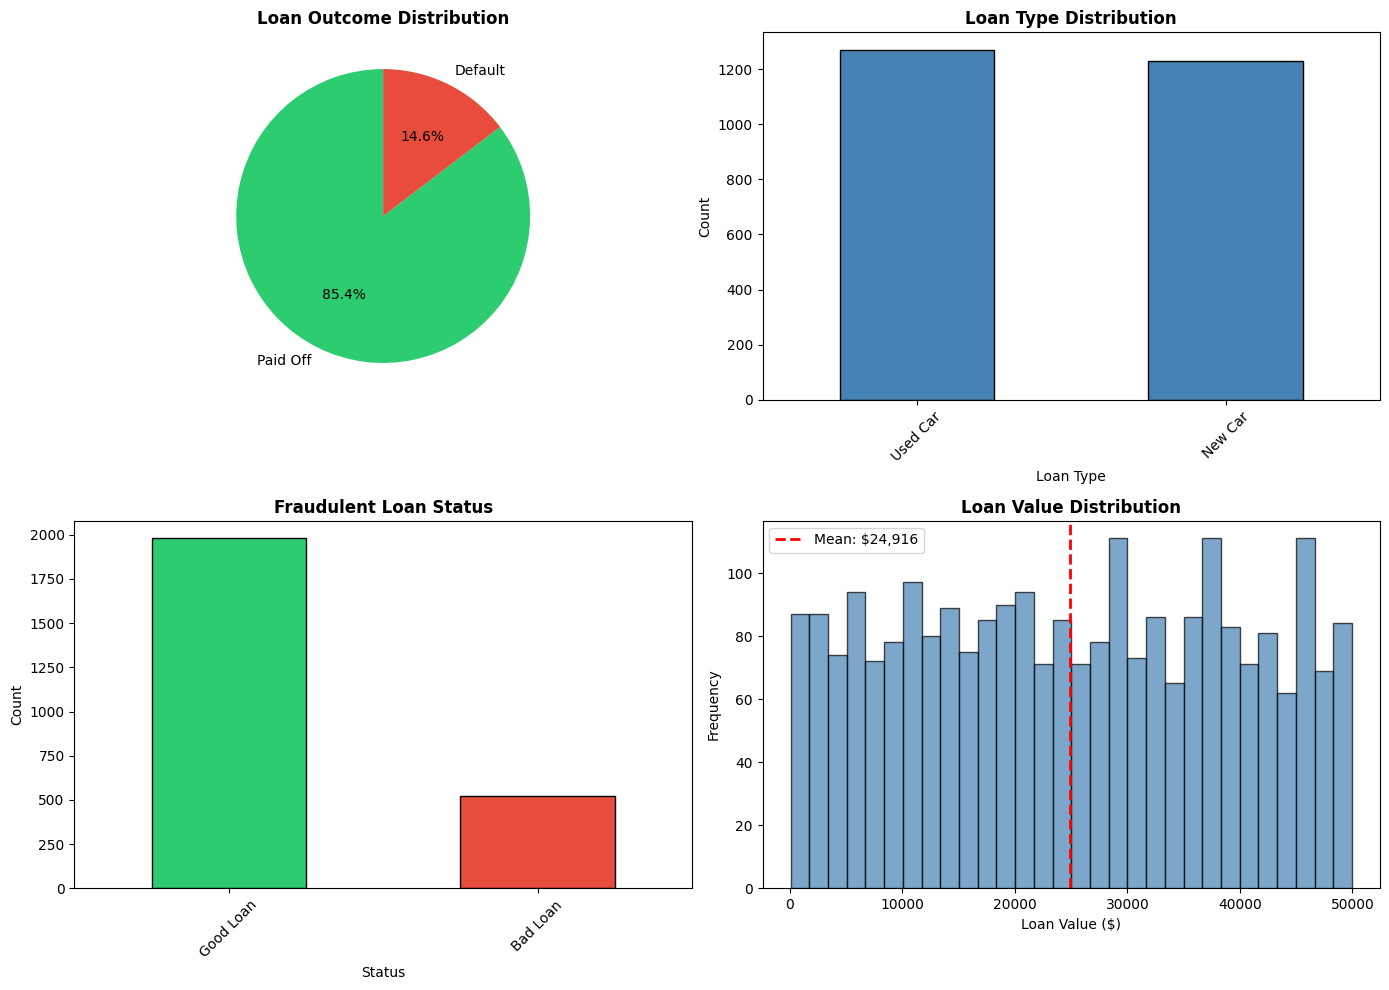

✅ Visualizations created!


In [112]:
# VISUALIZATIONS - LOAN DATA
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Loan Outcome Distribution (Pie Chart)
outcome_counts = loan_df['Loan Outcome'].value_counts()
axes[0, 0].pie(outcome_counts.values, labels=outcome_counts.index, autopct='%1.1f%%', 
               colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[0, 0].set_title('Loan Outcome Distribution', fontweight='bold', fontsize=12)

# 2. Loan Type Distribution (Bar Chart)
type_counts = loan_df['Loan Type'].value_counts()
type_counts.plot(kind='bar', ax=axes[0, 1], color='steelblue', edgecolor='black')
axes[0, 1].set_title('Loan Type Distribution', fontweight='bold', fontsize=12)
axes[0, 1].set_xlabel('Loan Type')
axes[0, 1].set_ylabel('Count')
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. Fraudulent Loan Status (Bar Chart)
fraud_counts = loan_df['Fraudlent Loan'].value_counts()
fraud_counts.plot(kind='bar', ax=axes[1, 0], color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[1, 0].set_title('Fraudulent Loan Status', fontweight='bold', fontsize=12)
axes[1, 0].set_xlabel('Status')
axes[1, 0].set_ylabel('Count')
axes[1, 0].tick_params(axis='x', rotation=45)

# 4. Loan Value Distribution (Histogram)
axes[1, 1].hist(loan_df['Loan Value at Origination'], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
mean_val = loan_df['Loan Value at Origination'].mean()
axes[1, 1].axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: ${mean_val:,.0f}')
axes[1, 1].set_title('Loan Value Distribution', fontweight='bold', fontsize=12)
axes[1, 1].set_xlabel('Loan Value ($)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

print("✅ Visualizations created!")

In [113]:
# AVERAGE LOAN VALUES BY OUTCOME
print('='*70)
print('LOAN VALUE ANALYSIS BY OUTCOME')
print('='*70)

value_by_outcome = loan_df.groupby('Loan Outcome')['Loan Value at Origination'].agg([
    ('Average', 'mean'),
    ('Median', 'median'),
    ('Min', 'min'),
    ('Max', 'max'),
    ('Count', 'count')
]).round(2)

display(value_by_outcome)
print('='*70)

LOAN VALUE ANALYSIS BY OUTCOME


,Average,Median,Min,Max,Count
Loan Outcome,,,,,
Default,25864.15,27477.85,103.51,49663.62,366
Paid Off,24753.87,24629.62,56.38,49954.09,2134


In [114]:
# PIVOT TABLE 2: Outcome by Fraudulent Status
print('='*70)
print('PIVOT TABLE: OUTCOME BY FRAUDULENT LOAN STATUS')
print('='*70)

pivot_outcome_fraud = pd.pivot_table(
    loan_df,
    index='Loan Outcome',
    columns='Fraudlent Loan',
    values='ID',
    aggfunc='count',
    fill_value=0,
    margins=True,
    margins_name='Total'
)

display(pivot_outcome_fraud)

# Calculate default rates
print("\n💡 Fraud Impact Analysis:")
bad_loan_default = loan_df[(loan_df['Fraudlent Loan'] == 'Bad Loan') & (loan_df['Loan Outcome'] == 'Default')].shape[0]
bad_loan_total = loan_df[loan_df['Fraudlent Loan'] == 'Bad Loan'].shape[0]
good_loan_default = loan_df[(loan_df['Fraudlent Loan'] == 'Good Loan') & (loan_df['Loan Outcome'] == 'Default')].shape[0]
good_loan_total = loan_df[loan_df['Fraudlent Loan'] == 'Good Loan'].shape[0]

print(f"   • Bad Loans Default Rate: {bad_loan_default/bad_loan_total*100:.2f}%")
print(f"   • Good Loans Default Rate: {good_loan_default/good_loan_total*100:.2f}%")
print('='*70)

PIVOT TABLE: OUTCOME BY FRAUDULENT LOAN STATUS


Fraudlent Loan,Bad Loan,Good Loan,Total
Loan Outcome,,,
Default,279,87,366
Paid Off,241,1893,2134
Total,520,1980,2500



💡 Fraud Impact Analysis:
   • Bad Loans Default Rate: 53.65%
   • Good Loans Default Rate: 4.39%


In [115]:
# PIVOT TABLE 1: Loan Outcome by Type
print('='*70)
print('PIVOT TABLE: LOAN OUTCOME BY TYPE')
print('='*70)

pivot_outcome_type = pd.pivot_table(
    loan_df,
    index='Loan Outcome',
    columns='Loan Type',
    values='ID',
    aggfunc='count',
    fill_value=0,
    margins=True,
    margins_name='Total'
)

display(pivot_outcome_type)
print('='*70)

PIVOT TABLE: LOAN OUTCOME BY TYPE


Loan Type,New Car,Used Car,Total
Loan Outcome,,,
Default,165,201,366
Paid Off,1065,1069,2134
Total,1230,1270,2500


In [116]:
# KEY INSIGHTS - LOAN OUTCOMES
print('='*70)
print('LOAN OUTCOME ANALYSIS')
print('='*70)

print("\n📊 Loan Outcome Distribution:")
outcome_counts = loan_df['Loan Outcome'].value_counts()
for outcome, count in outcome_counts.items():
    pct = count / len(loan_df) * 100
    print(f"   • {outcome:15s}: {count:5,} loans ({pct:5.2f}%)")

total = len(loan_df)
defaults = len(loan_df[loan_df['Loan Outcome'] == 'Default'])
paid_off = len(loan_df[loan_df['Loan Outcome'] == 'Paid Off'])

print(f"\n💡 Key Metrics:")
print(f"   • Total Loans: {total:,}")
print(f"   • Default Rate: {defaults/total*100:.2f}%")
print(f"   • Success Rate: {paid_off/total*100:.2f}%")

print('='*70)

LOAN OUTCOME ANALYSIS

📊 Loan Outcome Distribution:
   • Paid Off       : 2,134 loans (85.36%)
   • Default        :   366 loans (14.64%)

💡 Key Metrics:
   • Total Loans: 2,500
   • Default Rate: 14.64%
   • Success Rate: 85.36%


In [117]:
# NUMERIC STATISTICS
print('='*70)
print('NUMERIC COLUMNS - STATISTICAL SUMMARY')
print('='*70)
numeric_cols = loan_df.select_dtypes(include=[np.number]).columns
display(loan_df[numeric_cols].describe().round(2))
print('='*70)

NUMERIC COLUMNS - STATISTICAL SUMMARY


,ID,Debt to Income Ratio,Age,Loan Value at Origination
count,2500.00,2500.00,2500.00,2500.00
mean,11250.50,0.48,49.32,24916.41
std,721.83,0.22,18.24,14380.57
min,10001.00,0.10,18.00,56.38
25%,10625.75,0.29,34.00,12458.88
50%,11250.50,0.48,49.00,24911.23
75%,11875.25,0.67,65.00,37332.74
max,12500.00,0.85,80.00,49954.09


## Loan Data Analysis

## 3. Sales Leads Pivot Tables

Pivot tables help summarize and analyze your sales leads data.

In [118]:
# First, let's see what columns we have to work with
print("Available columns for pivot tables:")
print(sales_df.columns.tolist())
print("\nSample data:")
sales_df.head(10)

Available columns for pivot tables:
['id', 'Source', 'Purchase', 'Profit', 'Summary 1', 'Summary 1 (transposed)']

Sample data:


,id,Source,Purchase,Profit,Summary 1,Summary 1 (transposed)
0,1,List A,Buy,441,NaN,NaN
1,2,List A,No Buy,-82,List A,Buy
2,3,List A,No Buy,-33,List B,No Buy
3,4,List A,Buy,416,List C,NaN
4,5,List A,Buy,314,NaN,NaN
5,6,List A,No Buy,-164,NaN,NaN
6,7,List A,Buy,300,NaN,NaN
7,8,List A,Buy,340,NaN,NaN
8,9,List A,No Buy,-118,NaN,NaN
9,10,List A,No Buy,-70,NaN,NaN


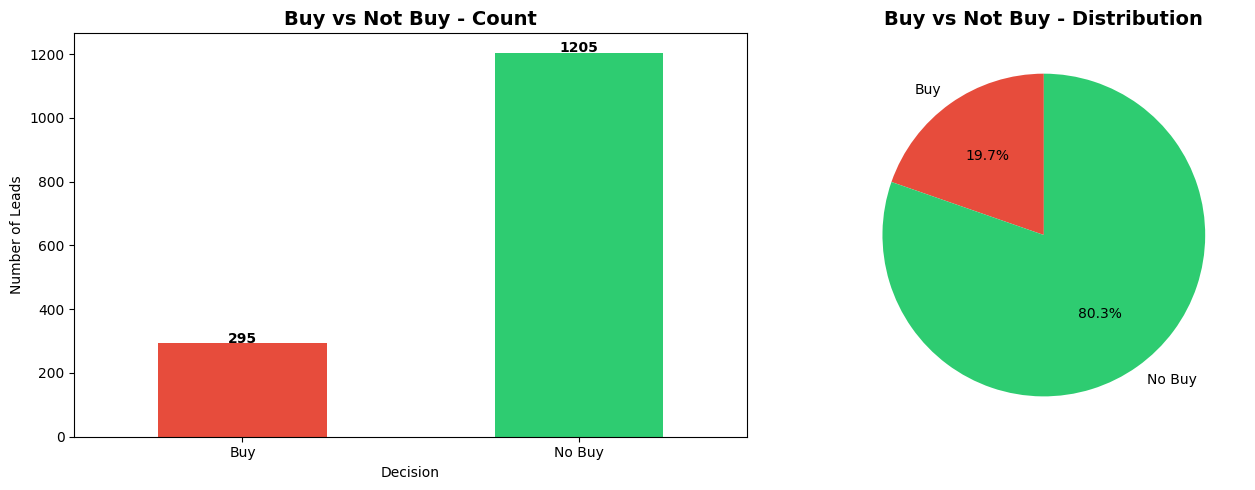


✓ Visualization created!


In [119]:
# Visualize Buy vs Not Buy
# Create a bar chart

try:
    # Try to use the auto-detected column
    if len(buy_columns) > 0:
        col_name = buy_columns[0]
        
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
        
        # Bar chart
        pivot_buy.plot(kind='bar', y='Count', ax=ax1, color=['#e74c3c', '#2ecc71'], legend=False)
        ax1.set_title('Buy vs Not Buy - Count', fontsize=14, fontweight='bold')
        ax1.set_xlabel('Decision')
        ax1.set_ylabel('Number of Leads')
        ax1.tick_params(axis='x', rotation=0)
        
        # Add count labels on bars
        for i, v in enumerate(pivot_buy['Count']):
            ax1.text(i, v + 0.5, str(int(v)), ha='center', fontweight='bold')
        
        # Pie chart
        pivot_buy['Count'].plot(kind='pie', ax=ax2, autopct='%1.1f%%', 
                                colors=['#e74c3c', '#2ecc71'], startangle=90)
        ax2.set_title('Buy vs Not Buy - Distribution', fontsize=14, fontweight='bold')
        ax2.set_ylabel('')
        
        plt.tight_layout()
        plt.show()
        
        print("\n✓ Visualization created!")
except:
    print("Run the cells above first to detect the buy/not buy column")

In [87]:
# OPTION 2: Manual - if automatic detection didn't work
# Replace 'YourColumnName' with the exact column name from above

# UNCOMMENT AND UPDATE THIS:
# buy_column = 'YourColumnName'  # <-- Put your actual column name here
# 
# pivot_buy_manual = pd.pivot_table(
#     sales_df,
#     index=buy_column,
#     values=sales_df.columns[0],
#     aggfunc='count'
# )
# 
# print("="*50)
# print("BUY vs NOT BUY COUNT")
# print("="*50)
# print(pivot_buy_manual)
# print(f"\nTotal: {pivot_buy_manual.sum()}")

In [88]:
# OPTION 1: If you have a column with "buy"/"not buy" values
# Replace 'Decision' with your actual column name

# Find columns that might contain buy/not buy
print("Looking for 'buy' related columns...")
buy_columns = [col for col in sales_df.columns if 'buy' in col.lower() or 'decision' in col.lower() or 'purchase' in col.lower()]
print(f"Possible columns: {buy_columns}")

if len(buy_columns) > 0:
    col_name = buy_columns[0]  # Use the first matching column
    print(f"\nUsing column: '{col_name}'")
    
    # Create pivot table
    pivot_buy = pd.pivot_table(
        sales_df,
        index=col_name,
        values=sales_df.columns[0],
        aggfunc='count'
    )
    pivot_buy.columns = ['Count']
    
    print("\n" + "="*50)
    print("BUY vs NOT BUY COUNT")
    print("="*50)
    print(pivot_buy)
    print(f"\nTotal Leads: {pivot_buy['Count'].sum()}")
    
    # Calculate percentages
    pivot_buy['Percentage'] = (pivot_buy['Count'] / pivot_buy['Count'].sum() * 100).round(2)
    print("\n" + "="*50)
    print("WITH PERCENTAGES")
    print("="*50)
    print(pivot_buy)
else:
    print("\nNo 'buy' column found automatically.")
    print("Please check the column names above and update the code manually.")

Looking for 'buy' related columns...
Possible columns: ['Purchase']

Using column: 'Purchase'

BUY vs NOT BUY COUNT
          Count
Purchase       
Buy         295
No Buy     1205

Total Leads: 1500

WITH PERCENTAGES
          Count  Percentage
Purchase                   
Buy         295       19.67
No Buy     1205       80.33


In [89]:
# Simple count of Buy vs Not Buy
# This will automatically find the right column

# First, let's see all the columns to find the "buy" column
print("Columns in your data:")
for i, col in enumerate(sales_df.columns):
    print(f"{i}: {col}")
    
print("\n" + "="*50)
print("PREVIEW OF DATA:")
print("="*50)
sales_df.head()

Columns in your data:
0: id
1: Source
2: Purchase
3: Profit
4: Summary 1
5: Summary 1 (transposed)

PREVIEW OF DATA:


,id,Source,Purchase,Profit,Summary 1,Summary 1 (transposed)
0,1,List A,Buy,441,NaN,NaN
1,2,List A,No Buy,-82,List A,Buy
2,3,List A,No Buy,-33,List B,No Buy
3,4,List A,Buy,416,List C,NaN
4,5,List A,Buy,314,NaN,NaN


### Count of Buy vs Not Buy

### Pivot Table Examples

Below are common pivot table patterns. Customize based on your column names.

In [90]:
# PIVOT TABLE TEMPLATE
# Replace 'column_name' with your actual column names from the data

# Example 1: Simple count pivot table
# Count of leads by category
# pivot1 = pd.pivot_table(
#     sales_df,
#     values='id',  # or any column to count
#     index='category',  # replace with your grouping column
#     aggfunc='count'
# )
# print("Lead Count by Category:")
# print(pivot1)

# Example 2: Multiple aggregations
# pivot2 = pd.pivot_table(
#     sales_df,
#     values='score',  # replace with numeric column
#     index='source',  # replace with row grouping
#     columns='status',  # replace with column grouping
#     aggfunc=['sum', 'mean', 'count'],
#     fill_value=0
# )
# print("\nMulti-aggregation Pivot:")
# print(pivot2)

# Uncomment and customize based on your actual columns
print("Review your columns above, then uncomment and customize these pivot table templates")

Review your columns above, then uncomment and customize these pivot table templates


### Quick Reference: Pivot Table Parameters

**Common Parameters:**
- `index`: Row grouping column(s)
- `columns`: Column grouping (optional, creates cross-tab)
- `values`: Column to aggregate
- `aggfunc`: How to aggregate - `'count'`, `'sum'`, `'mean'`, `'median'`, `'min'`, `'max'`
- `fill_value`: Replace NaN with this value (usually 0)
- `margins`: Add row/column totals (True/False)

**Multiple Aggregations:**
```python
aggfunc=['count', 'sum', 'mean']
```

**Custom Aggregations:**
```python
aggfunc={'column1': 'sum', 'column2': 'mean'}
```

In [91]:
# PIVOT TABLE 6: Export to Excel
# Save your pivot table back to Excel

# pivot_to_export = pd.pivot_table(
#     sales_df,
#     index='Category',
#     columns='Status',
#     values=sales_df.columns[0],
#     aggfunc='count',
#     fill_value=0,
#     margins=True
# )
# 
# # Save to Excel
# pivot_to_export.to_excel('sales_leads_pivot_table.xlsx')
# print("✓ Pivot table exported to: sales_leads_pivot_table.xlsx")

In [92]:
# PIVOT TABLE 5: Visualize Your Pivot Table
# Create a bar chart from pivot table results

# Example visualization:
# pivot_for_viz = pd.pivot_table(
#     sales_df,
#     index='Category',
#     values=sales_df.columns[0],
#     aggfunc='count'
# )
# 
# fig, ax = plt.subplots(figsize=(10, 6))
# pivot_for_viz.plot(kind='bar', ax=ax, color='steelblue')
# plt.title('Leads by Category', fontsize=14, fontweight='bold')
# plt.xlabel('Category')
# plt.ylabel('Number of Leads')
# plt.xticks(rotation=45, ha='right')
# plt.tight_layout()
# plt.show()

In [93]:
# PIVOT TABLE 4: Multiple Metrics
# Show multiple calculations at once

# pivot_multi = pd.pivot_table(
#     sales_df,
#     index='Category',
#     values='Score',
#     aggfunc={
#         'Score': ['count', 'mean', 'median', 'min', 'max', 'sum']
#     }
# ).round(2)
# pivot_multi.columns = ['Count', 'Mean', 'Median', 'Min', 'Max', 'Total']
# print("=== Comprehensive Analysis ===")
# print(pivot_multi)

In [94]:
# PIVOT TABLE 3: Numeric Analysis
# Analyze numeric values (scores, amounts, etc.)

# Example: Average score by category
# pivot_avg = pd.pivot_table(
#     sales_df,
#     index='Category',
#     values='Score',  # Replace with your numeric column
#     aggfunc='mean'
# ).round(2)
# print("=== Average Scores ===")
# print(pivot_avg)

In [95]:
# PIVOT TABLE 2: Two-Way Analysis
# Cross-tabulation of two categorical variables

# Example: Leads by Source and Status
# pivot_2way = pd.pivot_table(
#     sales_df,
#     index='Source',  # Replace with your row grouping
#     columns='Status',  # Replace with your column grouping
#     values=sales_df.columns[0],
#     aggfunc='count',
#     fill_value=0,
#     margins=True,  # Adds totals
#     margins_name='Total'
# )
# print("=== Two-Way Pivot Table ===")
# print(pivot_2way)

In [96]:
# PIVOT TABLE 1: Basic Count
# Count how many leads you have in each category

# Uncomment and replace 'Category' with your actual column name:
# pivot_count = pd.pivot_table(
#     sales_df,
#     index='Category',  # Replace with your grouping column
#     values=sales_df.columns[0],  # First column for counting
#     aggfunc='count'
# )
# print("=== Lead Count ===")
# print(pivot_count)
# print(f"\nTotal Leads: {pivot_count.sum()}")

## 5. Key Insights

Summary of findings and actionable insights.

In [97]:
# Calculate key metrics and insights
